# Quantum machine learning on PneumoniaMNIST

Chest X-ray classification (normal vs. pneumonia) using the quantum models.

Every quantum model is trained on the same 100-image balanced subset and compared against a
classical RBF SVM on identical features.

## 1. Setup

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import medmnist

from medmnist import INFO

seed = 42
np.random.seed(seed)

In [2]:
import sys
import sklearn
import pennylane
import qiskit
import torch

print("python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("scikit-learn", sklearn.__version__)
print("pennylane   ", pennylane.__version__)
print("qiskit      ", qiskit.__version__)
print("torch       ", torch.__version__)
print("medmnist    ", medmnist.__version__)

python       3.14.4
numpy        2.4.4
scikit-learn 1.8.0
pennylane    0.45.1
qiskit       2.3.0
torch        2.13.0+cpu
medmnist     3.0.2


### 1.1 Data

PneumoniaMNIST is 28x28 greyscale chest X-rays with a binary label. It ships with fixed
train/validation/test splits, so no splitting is done here.

In [3]:
data_flag = "pneumoniamnist"
info = INFO[data_flag]

PneumoniaData = getattr(medmnist, info["python_class"])

train_data = PneumoniaData(split="train", download=True)
val_data = PneumoniaData(split="val", download=True)
test_data = PneumoniaData(split="test", download=True)

In [4]:
x_train = train_data.imgs
y_train = train_data.labels.flatten()

x_val = val_data.imgs
y_val = val_data.labels.flatten()

x_test = test_data.imgs
y_test = test_data.labels.flatten()

print("Training:  ", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:      ", x_test.shape, y_test.shape)
print("Classes:", info["label"])

Training:   (4708, 28, 28) (4708,)
Validation: (524, 28, 28) (524,)
Test:       (624, 28, 28) (624,)
Classes: {'0': 'normal', '1': 'pneumonia'}


In [5]:
for name, y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    labels, counts = np.unique(y, return_counts=True)
    print(name, dict(zip(labels, counts)), " pneumonia fraction:", round(y.mean(), 3))

Train {np.uint8(0): np.int64(1214), np.uint8(1): np.int64(3494)}  pneumonia fraction: 0.742
Validation {np.uint8(0): np.int64(135), np.uint8(1): np.int64(389)}  pneumonia fraction: 0.742
Test {np.uint8(0): np.int64(234), np.uint8(1): np.int64(390)}  pneumonia fraction: 0.625


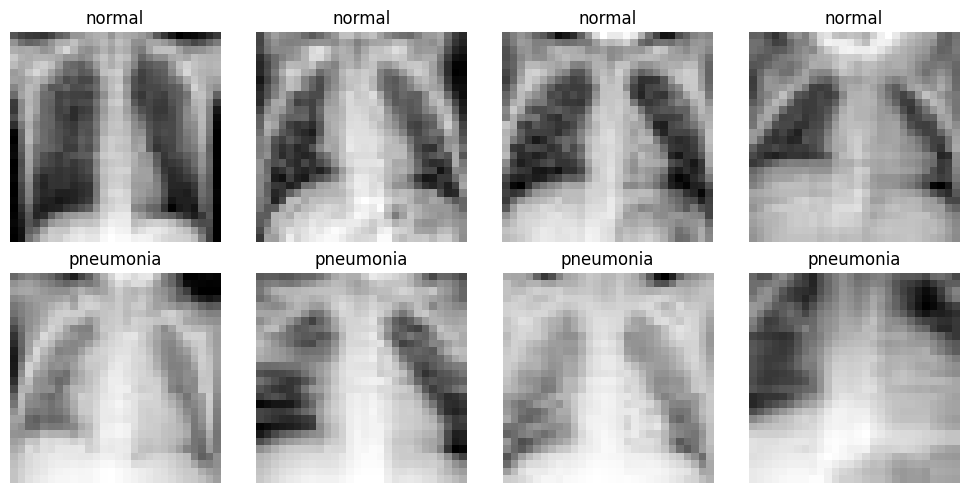

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for label in [0, 1]:
    indices = np.where(y_train == label)[0][:4]

    for i, idx in enumerate(indices):
        axes[label, i].imshow(x_train[idx], cmap="gray")
        axes[label, i].axis("off")
        axes[label, i].set_title(info["label"][str(label)])

plt.tight_layout()
plt.show()

In [7]:
for label in [0, 1]:
    images = x_train[y_train == label]
    print(info["label"][str(label)], " mean:", round(images.mean(), 2),
          " sd:", round(images.std(), 2))

normal  mean: 139.9  sd: 46.82
pneumonia  mean: 147.9  sd: 41.29


## 2. Preprocessing

784 pixels is far more than 4 qubits can hold, so the images are normalised, flattened, and
reduced with PCA. `MaxAbsScaler` then puts every component in `[-1, 1]`, which is what the
angle-based feature maps expect.


In [8]:
x_train_norm = x_train.astype("float64") / 255.0
x_val_norm = x_val.astype("float64") / 255.0
x_test_norm = x_test.astype("float64") / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_val_flat = x_val_norm.reshape(len(x_val_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print(x_train_flat.shape, x_val_flat.shape, x_test_flat.shape)
print("Pixel range:", x_train_flat.min(), x_train_flat.max())

(4708, 784) (524, 784) (624, 784)
Pixel range: 0.0 1.0


In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4, random_state=seed)

x_train_pca = pca.fit_transform(x_train_flat)
x_val_pca = pca.transform(x_val_flat)
x_test_pca = pca.transform(x_test_flat)

print(x_train_pca.shape, x_val_pca.shape, x_test_pca.shape)
print("Explained variance:", np.round(pca.explained_variance_ratio_, 4))
print("Total:", round(float(pca.explained_variance_ratio_.sum()), 4))

(4708, 4) (524, 4) (624, 4)
Explained variance: [0.3787 0.0965 0.0701 0.0523]
Total: 0.5976


In [10]:
for n in [2, 4, 8, 16]:
    print(n, "components:",
          round(float(PCA(n_components=n, random_state=seed)
                      .fit(x_train_flat).explained_variance_ratio_.sum()), 4))

2 components: 0.4752
4 components: 0.5976


8 components: 0.7288
16 components: 0.835


In [11]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()

x_train_scaled = scaler.fit_transform(x_train_pca)
x_val_scaled = scaler.transform(x_val_pca)
x_test_scaled = scaler.transform(x_test_pca)

print("Train range:", round(float(x_train_scaled.min()), 3), round(float(x_train_scaled.max()), 3))
print("Val range:  ", round(float(x_val_scaled.min()), 3), round(float(x_val_scaled.max()), 3))

Train range: -1.0 1.0
Val range:   -0.952 0.817


## 3. Classical baseline

An RBF SVM on the same four components, first on all 4,708 training images. This is the number
the quantum models have to beat.

In [12]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

svm_full = SVC(kernel="rbf")

start = time.time()
svm_full.fit(x_train_scaled, y_train)
full_time = time.time() - start

y_val_full = svm_full.predict(x_val_scaled)

print("Validation accuracy:", round(accuracy_score(y_val, y_val_full), 4))
print("Training time:", round(full_time, 2), "seconds")
print(confusion_matrix(y_val, y_val_full))
print(classification_report(y_val, y_val_full, target_names=["normal", "pneumonia"]))

Validation accuracy: 0.9237
Training time: 0.09 seconds
[[113  22]
 [ 18 371]]
              precision    recall  f1-score   support

      normal       0.86      0.84      0.85       135
   pneumonia       0.94      0.95      0.95       389

    accuracy                           0.92       524
   macro avg       0.90      0.90      0.90       524
weighted avg       0.92      0.92      0.92       524



### 3.1 A balanced subset for the quantum models

A quantum kernel needs one circuit evaluation per pair of samples, so fitting on all 4,708
images means 22 million circuits. Everything below therefore uses a balanced 100-image training
subset and a 50-image validation subset, drawn once and shared by every model so the comparison
stays controlled.

The subset is balanced even though the full dataset is 74% pneumonia -- with 100 samples an
unbalanced draw would let a model score well by guessing the majority class.

In [13]:
rng = np.random.default_rng(seed)

train_0 = rng.choice(np.where(y_train == 0)[0], 50, replace=False)
train_1 = rng.choice(np.where(y_train == 1)[0], 50, replace=False)

val_0 = rng.choice(np.where(y_val == 0)[0], 25, replace=False)
val_1 = rng.choice(np.where(y_val == 1)[0], 25, replace=False)

train_idx = np.concatenate([train_0, train_1])
val_idx = np.concatenate([val_0, val_1])

x_train_q = x_train_scaled[train_idx]
y_train_q = y_train[train_idx]

x_val_q = x_val_scaled[val_idx]
y_val_q = y_val[val_idx]

print("Train subset:", x_train_q.shape, np.bincount(y_train_q))
print("Val subset:  ", x_val_q.shape, np.bincount(y_val_q))
print("Mean |feature|:", round(float(np.abs(x_train_q).mean()), 4))

Train subset: (100, 4) [50 50]
Val subset:   (50, 4) [25 25]
Mean |feature|: 0.2027


In [14]:
svm_rbf = SVC(kernel="rbf")

start = time.time()
svm_rbf.fit(x_train_q, y_train_q)
rbf_time = time.time() - start

y_val_rbf = svm_rbf.predict(x_val_q)

print("Validation accuracy:", round(accuracy_score(y_val_q, y_val_rbf), 4))
print("Training time:", round(rbf_time, 4), "seconds")
print(confusion_matrix(y_val_q, y_val_rbf))
print(classification_report(y_val_q, y_val_rbf, target_names=["normal", "pneumonia"]))

Validation accuracy: 0.86
Training time: 0.0009 seconds
[[23  2]
 [ 5 20]]
              precision    recall  f1-score   support

      normal       0.82      0.92      0.87        25
   pneumonia       0.91      0.80      0.85        25

    accuracy                           0.86        50
   macro avg       0.87      0.86      0.86        50
weighted avg       0.87      0.86      0.86        50



## 4. Quantum kernel SVMs

The quantum kernel is the fidelity between two encoded states: run the feature map on `a`, run
its adjoint on `b`, and read the probability of measuring all zeros. If the two states are
identical that probability is 1, so `kernel_circ(a, a)[0]` is a useful sanity check.



### 4.1 Angle embedding

In [15]:
import pennylane as qml

nqubits = 4
dev = qml.device("default.qubit", wires=nqubits)


@qml.qnode(dev)
def kernel_circ(a, b):
    qml.AngleEmbedding(a, wires=range(nqubits))
    qml.adjoint(qml.AngleEmbedding)(b, wires=range(nqubits))
    return qml.probs(wires=range(nqubits))


print("Self-fidelity:", kernel_circ(x_train_q[0], x_train_q[0])[0])
print("Two different samples:", kernel_circ(x_train_q[0], x_train_q[1])[0])

Self-fidelity: 0.9999999999999996
Two different samples: 0.795328962312466


In [16]:
def qkernel(A, B):
    return np.array([[kernel_circ(a, b)[0] for b in B] for a in A])


qsvm_angle = SVC(kernel=qkernel)

start = time.time()
qsvm_angle.fit(x_train_q, y_train_q)
angle_time = time.time() - start

y_val_angle = qsvm_angle.predict(x_val_q)

print("Validation accuracy:", round(accuracy_score(y_val_q, y_val_angle), 4))
print("Training time:", round(angle_time, 1), "seconds")
print(confusion_matrix(y_val_q, y_val_angle))
print(classification_report(y_val_q, y_val_angle, target_names=["normal", "pneumonia"]))

Validation accuracy: 0.84
Training time: 9.5 seconds
[[22  3]
 [ 5 20]]
              precision    recall  f1-score   support

      normal       0.81      0.88      0.85        25
   pneumonia       0.87      0.80      0.83        25

    accuracy                           0.84        50
   macro avg       0.84      0.84      0.84        50
weighted avg       0.84      0.84      0.84        50



### 4.2 ZZ feature map

ZZFeatureMap: a Hadamard and an `RZ` on each qubit, then
for every pair a rotation conjugated by two `CZ` gates.

In [17]:
from itertools import combinations


def ZZFeatureMap(nqubits, data):
    nload = min(len(data), nqubits)

    for i in range(nload):
        qml.Hadamard(i)
        qml.RZ(2.0 * data[i], wires=i)

    for q0, q1 in combinations(range(nload), 2):
        qml.CZ(wires=[q0, q1])
        qml.RZ(2.0 * (np.pi - data[q0]) * (np.pi - data[q1]), wires=q1)
        qml.CZ(wires=[q0, q1])


@qml.qnode(dev)
def zz_kernel_circ(a, b):
    ZZFeatureMap(nqubits, a)
    qml.adjoint(ZZFeatureMap)(nqubits, b)
    return qml.probs(wires=range(nqubits))


print("Self-fidelity:", zz_kernel_circ(x_train_q[0], x_train_q[0])[0])

Self-fidelity: 0.9999999999999996


In [18]:
def zz_qkernel(A, B):
    return np.array([[zz_kernel_circ(a, b)[0] for b in B] for a in A])


qsvm_zz = SVC(kernel=zz_qkernel)

start = time.time()
qsvm_zz.fit(x_train_q, y_train_q)
zz_time = time.time() - start

y_val_zz = qsvm_zz.predict(x_val_q)

print("Validation accuracy:", round(accuracy_score(y_val_q, y_val_zz), 4))
print("Training time:", round(zz_time, 1), "seconds")
print(confusion_matrix(y_val_q, y_val_zz))
print(classification_report(y_val_q, y_val_zz, target_names=["normal", "pneumonia"]))

Validation accuracy: 0.76
Training time: 36.5 seconds
[[21  4]
 [ 8 17]]
              precision    recall  f1-score   support

      normal       0.72      0.84      0.78        25
   pneumonia       0.81      0.68      0.74        25

    accuracy                           0.76        50
   macro avg       0.77      0.76      0.76        50
weighted avg       0.77      0.76      0.76        50



### 4.3 Does that feature map entangle?

The ZZ map is supposed to create correlations between qubits that a classical kernel cannot
cheaply reproduce -- that is the whole argument for using it. But `CZ` is diagonal, `RZ` is
diagonal, diagonal matrices commute, and `CZ @ CZ = I`. So the sandwich

    CZ(q0, q1) . RZ(angle, q1) . CZ(q0, q1)

should collapse to the bare `RZ`, leaving a single-qubit phase and no entanglement at all.

Two checks: delete every `CZ` and see whether the encoded state changes, and measure the
von Neumann entropy of one qubit, which is exactly zero for a product state.

In [19]:
def ZZFeatureMap_noCZ(nqubits, data):
    nload = min(len(data), nqubits)

    for i in range(nload):
        qml.Hadamard(i)
        qml.RZ(2.0 * data[i], wires=i)

    for q0, q1 in combinations(range(nload), 2):
        qml.RZ(2.0 * (np.pi - data[q0]) * (np.pi - data[q1]), wires=q1)


def ZZFeatureMap_cnot(nqubits, data):
    nload = min(len(data), nqubits)

    for i in range(nload):
        qml.Hadamard(i)
        qml.RZ(2.0 * data[i], wires=i)

    for q0, q1 in combinations(range(nload), 2):
        qml.CNOT(wires=[q0, q1])
        qml.RZ(2.0 * (np.pi - data[q0]) * (np.pi - data[q1]), wires=q1)
        qml.CNOT(wires=[q0, q1])


@qml.qnode(dev)
def state_book(x):
    ZZFeatureMap(nqubits, x)
    return qml.state()


@qml.qnode(dev)
def state_noCZ(x):
    ZZFeatureMap_noCZ(nqubits, x)
    return qml.state()


@qml.qnode(dev)
def entropy_book(x):
    ZZFeatureMap(nqubits, x)
    return qml.vn_entropy(wires=[0])


@qml.qnode(dev)
def entropy_cnot(x):
    ZZFeatureMap_cnot(nqubits, x)
    return qml.vn_entropy(wires=[0])


probe = x_train_q[:20]

diff = max(np.abs(state_book(x) - state_noCZ(x)).max() for x in probe)
print("Max state change from deleting every CZ:", f"{diff:.3e}")

for tag, fn in [("book (CZ)  ", entropy_book), ("CNOT version", entropy_cnot)]:
    v = np.array([float(fn(x)) for x in probe])
    print(f"Entanglement entropy, {tag}  mean={v.mean():.3e}  max={v.max():.3e}")

Max state change from deleting every CZ: 0.000e+00
Entanglement entropy, book (CZ)    mean=1.441e-15  max=8.669e-15
Entanglement entropy, CNOT version  mean=6.263e-01  max=6.931e-01


The `CZ` gates are exact no-ops and the encoded state is a product state to machine precision.
The book's ZZ feature map has no two-qubit interaction in it.

Substituting `CNOT` -- which is not diagonal -- gives a genuine ZZ interaction. Both versions
are kept below so the two become a controlled comparison: identical angles, identical
structure, one gate different.

In [20]:
@qml.qnode(dev)
def zz_cnot_kernel_circ(a, b):
    ZZFeatureMap_cnot(nqubits, a)
    qml.adjoint(ZZFeatureMap_cnot)(nqubits, b)
    return qml.probs(wires=range(nqubits))


def zz_cnot_qkernel(A, B):
    return np.array([[zz_cnot_kernel_circ(a, b)[0] for b in B] for a in A])


qsvm_zz_cnot = SVC(kernel=zz_cnot_qkernel)

start = time.time()
qsvm_zz_cnot.fit(x_train_q, y_train_q)
zz_cnot_time = time.time() - start

y_val_zz_cnot = qsvm_zz_cnot.predict(x_val_q)

print("Validation accuracy:", round(accuracy_score(y_val_q, y_val_zz_cnot), 4))
print("Training time:", round(zz_cnot_time, 1), "seconds")
print(confusion_matrix(y_val_q, y_val_zz_cnot))

Validation accuracy: 0.78
Training time: 33.8 seconds
[[20  5]
 [ 6 19]]


### 4.4 The same thing in Qiskit

The book imports `ZZFeatureMap`, `QuantumKernel` and `AerSimulator` from
`qiskit.circuit.library`, `qiskit_machine_learning.kernels` and `qiskit.providers.aer`. In
Qiskit 2.x the class-style feature maps became functions (`zz_feature_map`), `QuantumKernel`
became `FidelityQuantumKernel`, and it runs on a reference primitive instead of an explicitly
passed simulator instance.

Printing the circuit shows the pair term is conjugated by `CX`, not `CZ`.

In [21]:
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

qiskit_feature_map = zz_feature_map(feature_dimension=4, reps=1)

print(qiskit_feature_map.decompose().draw("text"))

   ┌────────────┐┌───────────────┐                                         »
0: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[0]) ├──■──────────────────────────────────────»
   ├────────────┤├───────────────┤┌─┴─┐┌──────────────────────────────────┐»
1: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[1]) ├┤ X ├┤ U(0,0,(-π + x[0])*(-π + x[1])*2) ├»
   ├────────────┤├───────────────┤└───┘└──────────────────────────────────┘»
2: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[2]) ├─────────────────────────────────────────»
   ├────────────┤├───────────────┤                                         »
3: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[3]) ├─────────────────────────────────────────»
   └────────────┘└───────────────┘                                         »
«                                                                »
«0: ──■────■────────────────────────────────────────■─────────■──»
«   ┌─┴─┐  │                                        │         │  »
«1: ┤ X ├──┼────────────────────────────────────────┼────■────┼──»
«   └───┘┌─┴─┐┌────────────────────────

In [22]:
qiskit_kernel = FidelityQuantumKernel(feature_map=qiskit_feature_map)
qiskit_qsvc = QSVC(quantum_kernel=qiskit_kernel)

start = time.time()
qiskit_qsvc.fit(x_train_q, y_train_q)
qiskit_time = time.time() - start

y_val_qiskit = qiskit_qsvc.predict(x_val_q)

print("Validation accuracy:", round(accuracy_score(y_val_q, y_val_qiskit), 4))
print("Training time:", round(qiskit_time, 1), "seconds")
print(confusion_matrix(y_val_q, y_val_qiskit))
print(classification_report(y_val_q, y_val_qiskit, target_names=["normal", "pneumonia"]))

Validation accuracy: 0.78
Training time: 11.8 seconds
[[20  5]
 [ 6 19]]
              precision    recall  f1-score   support

      normal       0.77      0.80      0.78        25
   pneumonia       0.79      0.76      0.78        25

    accuracy                           0.78        50
   macro avg       0.78      0.78      0.78        50
weighted avg       0.78      0.78      0.78        50



## 5. Variational quantum classifier

The book's `TwoLocal` ansatz: a layer of `RY` rotations, a linear chain of `CNOT`s, repeated,
then a final rotation layer. Trained with Adam on the expectation of `PauliZ` on qubit 0 against
labels mapped to -1 and +1.

Inputs are passed as a batch. PennyLane broadcasts over the leading axis, which gives exactly
the same values as looping sample by sample and is about 30x faster.

In [23]:
import torch


def TwoLocal(nqubits, theta, reps=1):
    par = 0

    for r in range(reps):
        for q in range(nqubits):
            qml.RY(theta[par], wires=q)
            par += 1

        for q in range(nqubits - 1):
            qml.CNOT(wires=[q, q + 1])

    for q in range(nqubits):
        qml.RY(theta[par], wires=q)
        par += 1


n_layers = 2
nweights = (n_layers + 1) * nqubits

dev_vqc = qml.device("default.qubit", wires=nqubits)


@qml.qnode(dev_vqc, interface="torch")
def vqc_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(nqubits))
    TwoLocal(nqubits, weights, reps=n_layers)
    return qml.expval(qml.PauliZ(0))


print("Parameters:", nweights)

Parameters: 12


In [24]:
torch.manual_seed(seed)

weights = torch.nn.Parameter(2 * np.pi * torch.rand(nweights, dtype=torch.float64)) #create 12 parameters, randomly betn 0 and 2pi.
optimizer = torch.optim.Adam([weights], lr=0.05)
loss_fn = torch.nn.MSELoss()

x_train_t = torch.tensor(x_train_q, dtype=torch.float64)
x_val_t = torch.tensor(x_val_q, dtype=torch.float64)
y_train_pm = torch.tensor(y_train_q, dtype=torch.float64) * 2 - 1

for epoch in range(20):
    optimizer.zero_grad()
    outputs = vqc_circuit(x_train_t, weights)
    loss = loss_fn(outputs, y_train_pm)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch + 1:2d}: loss = {loss.item():.4f}")

Epoch  1: loss = 1.7746
Epoch  2: loss = 1.7030
Epoch  3: loss = 1.6174
Epoch  4: loss = 1.5206
Epoch  5: loss = 1.4159
Epoch  6: loss = 1.3086
Epoch  7: loss = 1.2054
Epoch  8: loss = 1.1138
Epoch  9: loss = 1.0410
Epoch 10: loss = 0.9925
Epoch 11: loss = 0.9697
Epoch 12: loss = 0.9694
Epoch 13: loss = 0.9845
Epoch 14: loss = 1.0060
Epoch 15: loss = 1.0261
Epoch 16: loss = 1.0397


Epoch 17: loss = 1.0451
Epoch 18: loss = 1.0425


Epoch 19: loss = 1.0336
Epoch 20: loss = 1.0206


In [25]:
with torch.no_grad():
    train_out = vqc_circuit(x_train_t, weights).numpy()
    val_out = vqc_circuit(x_val_t, weights).numpy()

y_train_vqc = ((1 - train_out) / 2 >= 0.5).astype(int)
y_val_vqc = ((1 - val_out) / 2 >= 0.5).astype(int)

print("Training accuracy:  ", round(accuracy_score(y_train_q, y_train_vqc), 4))
print("Validation accuracy:", round(accuracy_score(y_val_q, y_val_vqc), 4))
print("Output std:", round(float(val_out.std()), 4))
print("Output range:", round(float(val_out.min()), 4), "to", round(float(val_out.max()), 4))
print(confusion_matrix(y_val_q, y_val_vqc))

Training accuracy:   0.5
Validation accuracy: 0.5
Output std: 0.0461
Output range: 0.0378 to 0.3146
[[25  0]
 [25  0]]


### 5.1 Why that failed

The loss barely moves and the predictions collapse onto one class. Rather than guessing at
hyperparameters, measure the circuit.

Three things to look at: how wide the encoding angles actually are, how far apart the two
classes sit at the output, and which parameters receive gradient.

In [26]:
state_0 = [[1], [0]]
M = state_0 * np.conj(state_0).T


@qml.qnode(dev_vqc, interface="torch")
def vqc_circuit_book(inputs, theta):
    qml.AngleEmbedding(inputs, wires=range(nqubits))
    TwoLocal(nqubits, theta, reps=n_layers)
    return qml.expval(qml.Hermitian(M, wires=[0]))


y_tr_01 = torch.tensor(y_train_q.astype(np.float64), dtype=torch.float64)

print("Encoding angles per component, in radians:")
for j in range(nqubits):
    c = x_train_q[:, j]
    print(f"  f{j}: min={c.min():+.3f}  max={c.max():+.3f}  std={c.std():.3f}")
print("Mean |angle|:", round(float(np.abs(x_train_q).mean()), 4), "rad")

torch.manual_seed(0)
w_rand = torch.nn.Parameter(2 * np.pi * torch.rand(nweights, dtype=torch.float64))

out = vqc_circuit_book(x_train_t, w_rand)
loss = torch.nn.BCELoss()(torch.clamp(out, 1e-7, 1 - 1e-7), y_tr_01)
loss.backward()
o = out.detach().numpy()

print("\nOutput std:", round(float(o.std()), 4))
print("Class separation:", round(float(abs(o[y_train_q == 1].mean() - o[y_train_q == 0].mean())), 4))
print("BCE loss:", round(loss.item(), 4), " (0.6931 = coin flip)")
print("Gradient per parameter:", np.round(w_rand.grad.numpy(), 5))
print("Dead parameters:", int((w_rand.grad.abs() < 1e-8).sum()), "of", nweights)

Encoding angles per component, in radians:
  f0: min=-0.728  max=+0.482  std=0.236
  f1: min=-0.804  max=+0.454  std=0.294
  f2: min=-0.728  max=+0.562  std=0.232
  f3: min=-0.718  max=+0.619  std=0.236
Mean |angle|: 0.2027 rad

Output std: 0.0138
Class separation: 0.0001
BCE loss: 0.7482  (0.6931 = coin flip)
Gradient per parameter: [ 0.23183  0.10509 -0.0323   0.      -0.27872  0.042    0.      -0.
 -0.13549  0.       0.      -0.     ]
Dead parameters: 6 of 12


Two independent problems.

Half the parameters have exactly zero gradient. The `CNOT` chain runs `0 -> 1 -> 2 -> 3` while
the measurement is on qubit 0, so information flows away from the observable and most of the
circuit sits outside its light cone.

And the encoding angles are tiny. `AngleEmbedding` reads its input as radians, but after
`MaxAbsScaler` the mean absolute feature is about 0.2 rad, so all 100 samples land on nearly
the same state and the output has almost no spread to classify with.

### 5.2 Fix 1: close the entangling ring

Adding `CNOT(n-1, 0)` at the end of each repetition -- Qiskit calls this `'circular'`
entanglement -- gives every qubit a path back to qubit 0.

In [27]:
def TwoLocalRing(nqubits, theta, reps=1):
    par = 0

    for r in range(reps):
        for q in range(nqubits):
            qml.RY(theta[par], wires=q)
            par += 1

        for q in range(nqubits - 1):
            qml.CNOT(wires=[q, q + 1])
        qml.CNOT(wires=[nqubits - 1, 0])

    for q in range(nqubits):
        qml.RY(theta[par], wires=q)
        par += 1


@qml.qnode(dev_vqc, interface="torch")
def vqc_circuit_ring(inputs, theta):
    qml.AngleEmbedding(inputs, wires=range(nqubits))
    TwoLocalRing(nqubits, theta, reps=n_layers)
    return qml.expval(qml.Hermitian(M, wires=[0]))


torch.manual_seed(0)
w_ring = torch.nn.Parameter(2 * np.pi * torch.rand(nweights, dtype=torch.float64))

out = vqc_circuit_ring(x_train_t, w_ring)
loss = torch.nn.BCELoss()(torch.clamp(out, 1e-7, 1 - 1e-7), y_tr_01)
loss.backward()

print("Gradient per parameter:", np.round(w_ring.grad.numpy(), 5))
print("Dead parameters:", int((w_ring.grad.abs() < 1e-8).sum()), "of", nweights)

base = x_train_t[0].clone()
with torch.no_grad():
    y0 = float(vqc_circuit_ring(base, w_ring))
    for j in range(nqubits):
        pert = base.clone()
        pert[j] += 0.5
        print(f"  f{j} sensitivity: {abs(float(vqc_circuit_ring(pert, w_ring)) - y0):.6f}")

Gradient per parameter: [ 0.16306 -0.00931 -0.02459  0.04933  0.06136 -0.0045  -0.03961  0.03882
  0.12626  0.       0.       0.     ]
Dead parameters: 3 of 12
  f0 sensitivity: 0.006238
  f1 sensitivity: 0.065336
  f2 sensitivity: 0.012150
  f3 sensitivity: 0.021759


Dead parameters drop from 6 to 3, and every PCA component now moves the output. The remaining
3 are the final `RY` gates on the unmeasured wires, which nothing can reach after the last
entangling layer -- they are structurally inert at any depth.

### 5.3 Fix 2: encoding scale

`pi` is the largest scale that keeps every angle inside `[-pi, pi]`, the range over which the
cosine response of `AngleEmbedding` stays injective. Past that, different features start
aliasing onto the same state.

In [28]:
print(f"{'scale':>6} {'mean|angle|':>12} {'out std':>9} {'class sep':>10}")

for s in [1.0, np.pi / 2, np.pi, 2 * np.pi]:
    with torch.no_grad():
        o = vqc_circuit_ring(x_train_t * s, w_ring).numpy()
    sep = abs(o[y_train_q == 1].mean() - o[y_train_q == 0].mean())
    print(f"{s:6.3f} {float(np.abs(x_train_q).mean() * s):12.4f} {o.std():9.4f} {sep:10.4f}")

 scale  mean|angle|   out std  class sep
 1.000       0.2027    0.0205     0.0005
 1.571       0.3184    0.0431     0.0010
 3.142       0.6369    0.0934     0.0014
 6.283       1.2738    0.1252     0.0200


### 5.4 Retraining

Ring entanglement, angles scaled by `pi`, the `|0><0|` observable and `BCELoss` on 0/1 labels.

In [29]:
ANGLE_SCALE = np.pi

x_tr_s = torch.tensor(x_train_q * ANGLE_SCALE, dtype=torch.float64)
x_va_s = torch.tensor(x_val_q * ANGLE_SCALE, dtype=torch.float64)

torch.manual_seed(seed)
theta = torch.nn.Parameter(2 * np.pi * torch.rand(nweights, dtype=torch.float64))
opt = torch.optim.Adam([theta], lr=0.05)
bce = torch.nn.BCELoss()

for epoch in range(60):
    opt.zero_grad()
    out = vqc_circuit_ring(x_tr_s, theta)
    loss = bce(torch.clamp(out, 1e-7, 1 - 1e-7), y_tr_01)
    loss.backward()
    opt.step()

    if epoch == 0 or (epoch + 1) % 10 == 0:
        acc = accuracy_score(y_train_q, (out.detach().numpy() >= 0.5).astype(int))
        print(f"Epoch {epoch + 1:3d}: loss = {loss.item():.4f}  train acc = {acc:.3f}")

with torch.no_grad():
    tr_out = vqc_circuit_ring(x_tr_s, theta).numpy()
    va_out = vqc_circuit_ring(x_va_s, theta).numpy()

print("\nTraining accuracy:  ", round(accuracy_score(y_train_q, (tr_out >= 0.5).astype(int)), 4))
print("Validation accuracy:", round(accuracy_score(y_val_q, (va_out >= 0.5).astype(int)), 4))
print("Validation output range:", round(float(va_out.min()), 4), "to", round(float(va_out.max()), 4))
print(confusion_matrix(y_val_q, (va_out >= 0.5).astype(int)))

Epoch   1: loss = 0.8657  train acc = 0.440


Epoch  10: loss = 0.6853  train acc = 0.550


Epoch  20: loss = 0.6592  train acc = 0.630


Epoch  30: loss = 0.6534  train acc = 0.650


Epoch  40: loss = 0.6430  train acc = 0.710


Epoch  50: loss = 0.6285  train acc = 0.690


Epoch  60: loss = 0.6236  train acc = 0.660

Training accuracy:   0.66
Validation accuracy: 0.6
Validation output range: 0.2726 to 0.7187


[[12 13]
 [ 7 18]]


### 5.5 The decision threshold

An SVM learns a bias term, so cutting at `decision_function = 0` is a fitted choice. This
circuit has no bias, so cutting at 0.5 is arbitrary. The threshold is chosen by Youden's J on
the training scores only, then frozen and applied to validation.

`roc_curve` prepends an `inf` sentinel to its threshold array, which `argmax` will happily
select if it is not dropped first.

In [30]:
from sklearn.metrics import roc_auc_score, roc_curve


def youden_threshold(y, scores):
    fpr, tpr, thr = roc_curve(y, scores)
    finite = np.isfinite(thr)
    return float(thr[finite][np.argmax((tpr - fpr)[finite])])


best_t = youden_threshold(y_train_q, tr_out)
print("Threshold from training data:", round(best_t, 4))

print("\nThreshold 0.5")
print("  train acc:", round(accuracy_score(y_train_q, (tr_out >= 0.5).astype(int)), 4))
print("  val acc:  ", round(accuracy_score(y_val_q, (va_out >= 0.5).astype(int)), 4))

print("\nCalibrated threshold")
print("  train acc:", round(accuracy_score(y_train_q, (tr_out >= best_t).astype(int)), 4))
print("  val acc:  ", round(accuracy_score(y_val_q, (va_out >= best_t).astype(int)), 4))
print("  val AUC:  ", round(roc_auc_score(y_val_q, va_out), 4))
print(confusion_matrix(y_val_q, (va_out >= best_t).astype(int)))

Threshold from training data: 0.5247

Threshold 0.5
  train acc: 0.66
  val acc:   0.6

Calibrated threshold
  train acc: 0.71
  val acc:   0.62
  val AUC:   0.7136
[[17  8]
 [11 14]]


### 5.6 How deep should the ansatz be?

`reps` has to be bound per circuit rather than read from the global `n_layers`, otherwise every
depth in the sweep silently runs at depth 2 and returns a flat table instead of an error.

In [31]:
import pandas as pd


def make_vqc(reps):
    def circuit(inputs, theta):
        qml.AngleEmbedding(inputs, wires=range(nqubits))
        TwoLocalRing(nqubits, theta, reps=reps)
        return qml.expval(qml.Hermitian(M, wires=[0]))

    return qml.QNode(circuit, dev_vqc, interface="torch")


def train_vqc(reps, init_seed=seed, epochs=60, lr=0.05):
    circ = make_vqc(reps)
    nw = (reps + 1) * nqubits

    torch.manual_seed(init_seed)
    w = torch.nn.Parameter(2 * np.pi * torch.rand(nw, dtype=torch.float64))
    opt = torch.optim.Adam([w], lr=lr)
    bce = torch.nn.BCELoss()

    dead = None
    for epoch in range(epochs):
        opt.zero_grad()
        out = circ(x_tr_s, w)
        loss = bce(torch.clamp(out, 1e-7, 1 - 1e-7), y_tr_01)
        loss.backward()
        if dead is None:
            dead = int((w.grad.abs() < 1e-8).sum())
        opt.step()

    with torch.no_grad():
        tr = circ(x_tr_s, w).numpy()
        va = circ(x_va_s, w).numpy()

    t = youden_threshold(y_train_q, tr)

    return {
        "reps": reps,
        "init_seed": init_seed,
        "params": nw,
        "dead": dead,
        "threshold": round(t, 4),
        "train_AUC": round(roc_auc_score(y_train_q, tr), 4),
        "val_AUC": round(roc_auc_score(y_val_q, va), 4),
        "train_acc": round(accuracy_score(y_train_q, (tr >= t).astype(int)), 4),
        "val_acc": round(accuracy_score(y_val_q, (va >= t).astype(int)), 4),
        "weights": w.detach().numpy(),
    }


check = train_vqc(n_layers)
print({k: v for k, v in check.items() if k != "weights"})
print("Reproduces section 5.4:", abs(check["val_AUC"] - round(roc_auc_score(y_val_q, va_out), 4)) < 1e-9)

{'reps': 2, 'init_seed': 42, 'params': 12, 'dead': 3, 'threshold': 0.5247, 'train_AUC': 0.7464, 'val_AUC': 0.7136, 'train_acc': 0.71, 'val_acc': 0.62}
Reproduces section 5.4: True


In [32]:
sweep_rows = []

for reps in [1, 2, 4, 6]:
    start = time.time()
    row = train_vqc(reps)
    row["secs"] = round(time.time() - start, 1)
    row.pop("weights")
    sweep_rows.append(row)
    print(f"reps={reps}  params={row['params']:2d}  dead={row['dead']}  "
          f"train_AUC={row['train_AUC']:.4f}  val_AUC={row['val_AUC']:.4f}  "
          f"({row['secs']} s)", flush=True)

depth_sweep = pd.DataFrame(sweep_rows)
depth_sweep["gap"] = (depth_sweep.train_AUC - depth_sweep.val_AUC).round(4)
depth_sweep

reps=1  params= 8  dead=3  train_AUC=0.7096  val_AUC=0.4672  (0.3 s)


reps=2  params=12  dead=3  train_AUC=0.7464  val_AUC=0.7136  (0.4 s)


reps=4  params=20  dead=3  train_AUC=0.7944  val_AUC=0.6880  (0.6 s)


reps=6  params=28  dead=3  train_AUC=0.8096  val_AUC=0.7088  (0.7 s)


,reps,init_seed,params,dead,threshold,train_AUC,val_AUC,train_acc,val_acc,secs,gap
0,1,42,8,3,0.5888,0.7096,0.4672,0.69,0.46,0.3,0.2424
1,2,42,12,3,0.5247,0.7464,0.7136,0.71,0.62,0.4,0.0328
2,4,42,20,3,0.5144,0.7944,0.6880,0.74,0.58,0.6,0.1064
3,6,42,28,3,0.5622,0.8096,0.7088,0.75,0.62,0.7,0.1008


One seed is not enough to make a claim about depth, so the sweep is repeated over five weight
initializations. Only the initialization varies -- the data subset stays frozen because it is
shared with every other model, so the error bars describe optimizer initialization, not data
resampling.

In [33]:
INIT_SEEDS = [42, 0, 1, 2, 3]

ms_rows = []

for reps in [1, 2, 4, 6]:
    for s in INIT_SEEDS:
        row = train_vqc(reps, init_seed=s)
        row.pop("weights")
        ms_rows.append(row)
        print(f"reps={reps}  seed={s:3d}  train_AUC={row['train_AUC']:.4f}  "
              f"val_AUC={row['val_AUC']:.4f}  val_acc={row['val_acc']:.2f}", flush=True)
    print(flush=True)

multiseed = pd.DataFrame(ms_rows)

multiseed_summary = (
    multiseed.groupby("reps")
    .agg(params=("params", "first"),
         dead=("dead", "first"),
         train_AUC_mean=("train_AUC", "mean"), train_AUC_std=("train_AUC", "std"),
         val_AUC_mean=("val_AUC", "mean"), val_AUC_std=("val_AUC", "std"),
         val_AUC_min=("val_AUC", "min"), val_AUC_max=("val_AUC", "max"))
    .round(4)
    .reset_index()
)
multiseed_summary["gap"] = (multiseed_summary.train_AUC_mean - multiseed_summary.val_AUC_mean).round(4)
multiseed_summary

reps=1  seed= 42  train_AUC=0.7096  val_AUC=0.4672  val_acc=0.46


reps=1  seed=  0  train_AUC=0.7204  val_AUC=0.6560  val_acc=0.62


reps=1  seed=  1  train_AUC=0.7212  val_AUC=0.6624  val_acc=0.60


reps=1  seed=  2  train_AUC=0.7200  val_AUC=0.6656  val_acc=0.60


reps=1  seed=  3  train_AUC=0.7220  val_AUC=0.6624  val_acc=0.60


...

reps=6  seed=  0  train_AUC=0.8072  val_AUC=0.6880  val_acc=0.56


reps=6  seed=  1  train_AUC=0.8132  val_AUC=0.7232  val_acc=0.64


reps=6  seed=  2  train_AUC=0.8104  val_AUC=0.7008  val_acc=0.62


reps=6  seed=  3  train_AUC=0.8288  val_AUC=0.6672  val_acc=0.58


,reps,params,dead,train_AUC_mean,train_AUC_std,val_AUC_mean,val_AUC_std,val_AUC_min,val_AUC_max,gap
0,1,8,3,0.7186,0.0051,0.6227,0.0870,0.4672,0.6656,0.0959
1,2,12,3,0.7595,0.0097,0.7222,0.0293,0.6752,0.7472,0.0373
2,4,20,3,0.7927,0.0088,0.7062,0.0185,0.6880,0.7264,0.0865
3,6,28,3,0.8138,0.0086,0.6976,0.0213,0.6672,0.7232,0.1162


In [34]:
from scipy import stats

a = multiseed[multiseed.reps == 2].sort_values("init_seed").val_AUC.values
b = multiseed[multiseed.reps == 6].sort_values("init_seed").val_AUC.values
t, p = stats.ttest_rel(a, b)

print("reps=2 vs reps=6, paired over the same 5 initializations")
print(f"  mean difference {(a - b).mean():+.4f}   t = {t:.2f}   p = {p:.3f}")

reps=2 vs reps=6, paired over the same 5 initializations
  mean difference +0.0246   t = 1.55   p = 0.196


## 6. Evaluation on the full validation split

The 50-image subset was only ever a training-time convenience: its AUC standard error is about
+/-0.083, wide enough to swallow every difference between these models. Rescoring on all 524
validation images cuts that to about +/-0.029.

The training set does not change -- the same 100 images -- only the evaluation set.

Scores come from `decision_function` for the SVMs and from the raw `|0><0|` expectation for the
VQC, never from predicted labels and never from `probability=True`, which would refit with
Platt scaling and inject randomness none of the numbers above contain. Test scores are computed
in the same pass and set aside for section 9; no model or hyperparameter is chosen after this
point.

In [35]:
from sklearn.metrics import balanced_accuracy_score

VQC_REPS = 2

vqc_final = train_vqc(VQC_REPS)
vqc_circ = make_vqc(VQC_REPS)
vqc_theta = torch.tensor(vqc_final["weights"], dtype=torch.float64)

with torch.no_grad():
    vqc_tr = vqc_circ(x_tr_s, vqc_theta).numpy()
    vqc_val = vqc_circ(torch.tensor(x_val_scaled * ANGLE_SCALE, dtype=torch.float64), vqc_theta).numpy()
    vqc_test = vqc_circ(torch.tensor(x_test_scaled * ANGLE_SCALE, dtype=torch.float64), vqc_theta).numpy()

print("VQC scored on", len(vqc_val), "validation and", len(vqc_test), "test images")

VQC scored on 524 validation and 624 test images


In [36]:
kernel_models = [
    ("RBF SVM", svm_rbf, rbf_time),
    ("PennyLane Angle QSVM", qsvm_angle, angle_time),
    ("PennyLane ZZ QSVM (CZ)", qsvm_zz, zz_time),
    ("PennyLane ZZ QSVM (CNOT)", qsvm_zz_cnot, zz_cnot_time),
    ("Qiskit ZZ QSVM", qiskit_qsvc, qiskit_time),
]

train_scores = {}
val_scores = {}
test_scores = {}
train_times = {}

for name, model, secs in kernel_models:
    start = time.time()
    train_scores[name] = model.decision_function(x_train_q)
    val_scores[name] = model.decision_function(x_val_scaled)
    test_scores[name] = model.decision_function(x_test_scaled)
    train_times[name] = secs
    print(f"{name:26s} scored in {time.time() - start:5.0f} s", flush=True)

train_scores["PennyLane VQC"] = vqc_tr
val_scores["PennyLane VQC"] = vqc_val
test_scores["PennyLane VQC"] = vqc_test
train_times["PennyLane VQC"] = None

RBF SVM                    scored in     0 s


PennyLane Angle QSVM       scored in   111 s


PennyLane ZZ QSVM (CZ)     scored in   424 s


PennyLane ZZ QSVM (CNOT)   scored in   413 s


Qiskit ZZ QSVM             scored in   284 s


In [37]:
def evaluate(name, y_true, scores):
    t = youden_threshold(y_train_q, train_scores[name])
    s = scores[name]
    yhat = (s >= t).astype(int)
    return {
        "AUC": round(roc_auc_score(y_true, s), 4),
        "bal acc": round(balanced_accuracy_score(y_true, yhat), 4),
        "acc": round(accuracy_score(y_true, yhat), 4),
    }


def comparison_table(y_true, scores, label, with_time=False):
    table = []
    for name in scores:
        row = {"Model": name}
        row.update({label + " " + k: v for k, v in evaluate(name, y_true, scores).items()})
        if with_time:
            row["train time (s)"] = train_times[name]
        table.append(row)
    return (pd.DataFrame(table)
            .sort_values(label + " AUC", ascending=False)
            .reset_index(drop=True))


comparison = comparison_table(y_val, val_scores, "val", with_time=True)

n1, n0 = int((y_val == 1).sum()), int((y_val == 0).sum())
se = np.sqrt((n1 + n0 + 1) / (12.0 * n1 * n0))
print(f"AUC standard error on this split: +/-{se:.4f} "
      f"(vs +/-{np.sqrt(51 / 7500):.4f} on the 50-image subset)")

comparison

AUC standard error on this split: +/-0.0289 (vs +/-0.0825 on the 50-image subset)


,Model,val AUC,val bal acc,val acc,train time (s)
0,RBF SVM,0.9683,0.8772,0.8321,0.000923
1,PennyLane Angle QSVM,0.9618,0.8672,0.8244,9.465423
2,PennyLane ZZ QSVM (CNOT),0.9074,0.7905,0.8397,33.789409
3,Qiskit ZZ QSVM,0.9074,0.7905,0.8397,11.761965
4,PennyLane ZZ QSVM (CZ),0.7986,0.6879,0.5725,36.548076
5,PennyLane VQC,0.7429,0.6662,0.6336,NaN


### 6.1 Is the CNOT kernel the same model as Qiskit's?

Matching metrics to four decimals could be a coincidence, so we compare the raw scores.

In [38]:
cnot_s = val_scores["PennyLane ZZ QSVM (CNOT)"]
qk_s = val_scores["Qiskit ZZ QSVM"]
cz_s = val_scores["PennyLane ZZ QSVM (CZ)"]

print("CNOT-corrected PennyLane vs Qiskit zz_feature_map")
print(f"  max |score difference| = {np.abs(cnot_s - qk_s).max():.3e}")
print(f"  correlation            = {np.corrcoef(cnot_s, qk_s)[0, 1]:.10f}")
print(f"  AUC {roc_auc_score(y_val, cnot_s):.10f} vs {roc_auc_score(y_val, qk_s):.10f}")

print("\nThe book's CZ version vs Qiskit")
print(f"  max |score difference| = {np.abs(cz_s - qk_s).max():.3e}")
print(f"  correlation            = {np.corrcoef(cz_s, qk_s)[0, 1]:.6f}")

CNOT-corrected PennyLane vs Qiskit zz_feature_map
  max |score difference| = 7.825e-11
  correlation            = 1.0000000000
  AUC 0.9073978863 vs 0.9073978863

The book's CZ version vs Qiskit
  max |score difference| = 2.161e+00
  correlation            = 0.614775


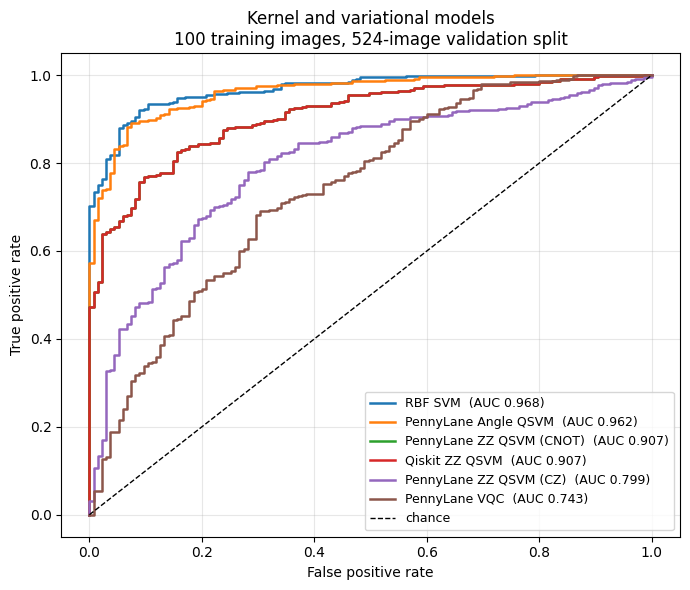

In [39]:
plt.figure(figsize=(7, 6))

for name, s in sorted(val_scores.items(), key=lambda kv: -roc_auc_score(y_val, kv[1])):
    fpr, tpr, _ = roc_curve(y_val, s)
    plt.plot(fpr, tpr, linewidth=1.8, label=f"{name}  (AUC {roc_auc_score(y_val, s):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Kernel and variational models\n100 training images, 524-image validation split")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Hybrid architectures 

The VQC needed a hand-picked encoding scale, and `pi` came out of a sweep rather than out of
training. A hybrid replaces that constant with a `Linear` layer that learns the encoding
angles, bounded to `[-pi, pi]` by `tanh * pi` -- the same injectivity constraint that motivated
the fixed scale, now learned per feature.

Two variants on the same 4-qubit ring circuit at `reps=2`:

- **Hybrid A** takes the same 4 PCA components as every other model, so its only advantage over
  the standalone VQC is the learned encoding.
- **Hybrid B** takes 8 components and learns the 8 -> 4 compression into the quantum layer,
  testing whether the bottleneck is the circuit or the four features.

Both use the VQC's recipe -- Adam, lr 0.05, 60 epochs, `BCELoss` -- over the same five
initializations, and the median seed is reported rather than the best.

In [40]:
import torch.nn as nn

pca8 = PCA(n_components=8, random_state=seed)

x_train_pca8 = pca8.fit_transform(x_train_flat)
x_val_pca8 = pca8.transform(x_val_flat)
x_test_pca8 = pca8.transform(x_test_flat)

scaler8 = MaxAbsScaler() 
x_train_s8 = scaler8.fit_transform(x_train_pca8)
x_val_s8 = scaler8.transform(x_val_pca8)
x_test_s8 = scaler8.transform(x_test_pca8)
x_train_q8 = x_train_s8[train_idx]

print("PCA(8) explained variance:", round(float(pca8.explained_variance_ratio_.sum()), 4))
print("PCA(4) explained variance:", round(float(pca.explained_variance_ratio_.sum()), 4))

PCA(8) explained variance: 0.7288
PCA(4) explained variance: 0.5976


In [41]:
class Hybrid(nn.Module):
    def __init__(self, n_in, reps=2):
        super().__init__()
        self.pre = nn.Linear(n_in, nqubits).double()
        self.circ = make_vqc(reps)
        self.theta = nn.Parameter(2 * np.pi * torch.rand((reps + 1) * nqubits, dtype=torch.float64))

    def angles(self, X):
        return torch.tanh(self.pre(X)) * np.pi

    def forward(self, X):
        return self.circ(self.angles(X), self.theta)


def train_hybrid(x_tr, x_va, x_te, n_in, init_seed, reps=2, epochs=60, lr=0.05):
    Xtr = torch.tensor(x_tr, dtype=torch.float64)
    Xva = torch.tensor(x_va, dtype=torch.float64)
    Xte = torch.tensor(x_te, dtype=torch.float64)

    torch.manual_seed(init_seed)
    model = Hybrid(n_in, reps)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCELoss()

    for epoch in range(epochs):
        opt.zero_grad()
        loss = bce(torch.clamp(model(Xtr), 1e-7, 1 - 1e-7), y_tr_01)
        loss.backward()
        opt.step()

    with torch.no_grad():
        out = {"tr": model(Xtr).numpy(), "val": model(Xva).numpy(), "test": model(Xte).numpy()}
        out["mean_angle"] = float(np.abs(model.angles(Xtr).numpy()).mean())

    out["loss"] = loss.item()
    out["params"] = sum(p.numel() for p in model.parameters())
    return out


def run_seeds(tag, fit, *args):
    print(tag, flush=True)
    runs = []

    for s in INIT_SEEDS:
        r = fit(*args, s)
        r["auc"] = roc_auc_score(y_val, r["val"])
        runs.append(r)
        print(f"  seed={s:3d}  params={r['params']:3d}  loss={r['loss']:.4f}  "
              f"val AUC={r['auc']:.4f}", flush=True)

    aucs = np.array([r["auc"] for r in runs])
    print(f"  mean val AUC = {aucs.mean():.4f} +/- {aucs.std(ddof=1):.4f}\n", flush=True)
    return runs[int(np.argsort(aucs)[len(aucs) // 2])], aucs


hybrid_a, aucs_a = run_seeds("Hybrid A, PCA-4, learned encoding",
                             train_hybrid, x_train_q, x_val_scaled, x_test_scaled, 4)
hybrid_b, aucs_b = run_seeds("Hybrid B, PCA-8, learned 8 -> 4 compression",
                             train_hybrid, x_train_q8, x_val_s8, x_test_s8, 8)

print("Mean |angle| learned by Hybrid A:", round(hybrid_a["mean_angle"], 3), "rad")
print("Fixed scale used by the standalone VQC:", round(float(np.abs(x_train_q).mean() * ANGLE_SCALE), 3), "rad")

Hybrid A, PCA-4, learned encoding


  seed= 42  params= 32  loss=0.2538  val AUC=0.9555


  seed=  0  params= 32  loss=0.2189  val AUC=0.9599


  seed=  1  params= 32  loss=0.2124  val AUC=0.9595


  seed=  2  params= 32  loss=0.2016  val AUC=0.9651


...

  seed=  1  params= 48  loss=0.1878  val AUC=0.9703


  seed=  2  params= 48  loss=0.1876  val AUC=0.9687


  seed=  3  params= 48  loss=0.1810  val AUC=0.9695


  mean val AUC = 0.9692 +/- 0.0008



Mean |angle| learned by Hybrid A: 1.7 rad
Fixed scale used by the standalone VQC: 0.637 rad


### 7.1 Control: is the quantum layer doing anything?

Hybrid A beats the standalone VQC on identical features with an identical circuit. The obvious
objection is that the `Linear` layer is doing the work.

The control keeps the front end exactly the same -- `Linear(n_in -> 4)`, `tanh * pi`, same
optimizer, same epochs, same five seeds -- and replaces the quantum layer with a classical
readout. If the circuit contributes discriminative power the hybrid should win. If it does not,
they tie.

In [42]:
class ClassicalControl(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.pre = nn.Linear(n_in, nqubits).double()
        self.out = nn.Linear(nqubits, 1).double()

    def forward(self, X):
        return torch.sigmoid(self.out(torch.tanh(self.pre(X)) * np.pi)).squeeze(-1)


def train_control(x_tr, x_va, x_te, n_in, init_seed, epochs=60, lr=0.05):
    Xtr = torch.tensor(x_tr, dtype=torch.float64)
    Xva = torch.tensor(x_va, dtype=torch.float64)
    Xte = torch.tensor(x_te, dtype=torch.float64)

    torch.manual_seed(init_seed)
    model = ClassicalControl(n_in)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCELoss()

    for epoch in range(epochs):
        opt.zero_grad()
        loss = bce(torch.clamp(model(Xtr), 1e-7, 1 - 1e-7), y_tr_01)
        loss.backward()
        opt.step()

    with torch.no_grad():
        out = {"tr": model(Xtr).numpy(), "val": model(Xva).numpy(), "test": model(Xte).numpy()}

    out["loss"] = loss.item()
    out["params"] = sum(p.numel() for p in model.parameters())
    return out


control_a, ctrl_aucs_a = run_seeds("Classical control, PCA-4",
                                   train_control, x_train_q, x_val_scaled, x_test_scaled, 4)
control_b, ctrl_aucs_b = run_seeds("Classical control, PCA-8",
                                   train_control, x_train_q8, x_val_s8, x_test_s8, 8)

print("Validation AUC on the 524-image split")
print(f"  standalone VQC     12 params, PCA-4   {roc_auc_score(y_val, vqc_val):.4f}  (seed 42)")
print(f"  Hybrid A  quantum, {hybrid_a['params']:2d} params, PCA-4   "
      f"{aucs_a.mean():.4f} +/- {aucs_a.std(ddof=1):.4f}")
print(f"  control   classical,{control_a['params']:2d} params, PCA-4   "
      f"{ctrl_aucs_a.mean():.4f} +/- {ctrl_aucs_a.std(ddof=1):.4f}")
print(f"  Hybrid B  quantum, {hybrid_b['params']:2d} params, PCA-8   "
      f"{aucs_b.mean():.4f} +/- {aucs_b.std(ddof=1):.4f}")
print(f"  control   classical,{control_b['params']:2d} params, PCA-8   "
      f"{ctrl_aucs_b.mean():.4f} +/- {ctrl_aucs_b.std(ddof=1):.4f}")

Classical control, PCA-4


  seed= 42  params= 25  loss=0.1970  val AUC=0.9625


  seed=  0  params= 25  loss=0.2017  val AUC=0.9618


  seed=  1  params= 25  loss=0.1945  val AUC=0.9633


  seed=  2  params= 25  loss=0.2005  val AUC=0.9621


...

  seed=  1  params= 41  loss=0.1490  val AUC=0.9724

  seed=  2  params= 41  loss=0.1273  val AUC=0.9703


  seed=  3  params= 41  loss=0.1435  val AUC=0.9709


  mean val AUC = 0.9714 +/- 0.0009



Validation AUC on the 524-image split
  standalone VQC     12 params, PCA-4   0.7429  (seed 42)
  Hybrid A  quantum, 32 params, PCA-4   0.9604 +/- 0.0036
  control   classical,25 params, PCA-4   0.9625 +/- 0.0006
  Hybrid B  quantum, 48 params, PCA-8   0.9692 +/- 0.0008
  control   classical,41 params, PCA-8   0.9714 +/- 0.0009


## 8. All models on the validation split

In [43]:
for tag, run in [("Hybrid A (PCA-4)", hybrid_a),
                 ("Hybrid B (PCA-8)", hybrid_b),
                 ("Classical control (PCA-4)", control_a),
                 ("Classical control (PCA-8)", control_b)]:
    train_scores[tag] = run["tr"]
    val_scores[tag] = run["val"]
    test_scores[tag] = run["test"]
    train_times[tag] = None

final_comparison = comparison_table(y_val, val_scores, "val", with_time=True)
final_comparison

,Model,val AUC,val bal acc,val acc,train time (s)
0,Classical control (PCA-8),0.9710,0.9146,0.8912,NaN
1,Hybrid B (PCA-8),0.9689,0.9190,0.9084,NaN
2,RBF SVM,0.9683,0.8772,0.8321,0.000923
3,Classical control (PCA-4),0.9625,0.8762,0.8378,NaN
4,PennyLane Angle QSVM,0.9618,0.8672,0.8244,9.465423
5,Hybrid A (PCA-4),0.9599,0.8737,0.8340,NaN
6,Qiskit ZZ QSVM,0.9074,0.7905,0.8397,11.761965
7,PennyLane ZZ QSVM (CNOT),0.9074,0.7905,0.8397,33.789409
8,PennyLane ZZ QSVM (CZ),0.7986,0.6879,0.5725,36.548076
9,PennyLane VQC,0.7429,0.6662,0.6336,NaN


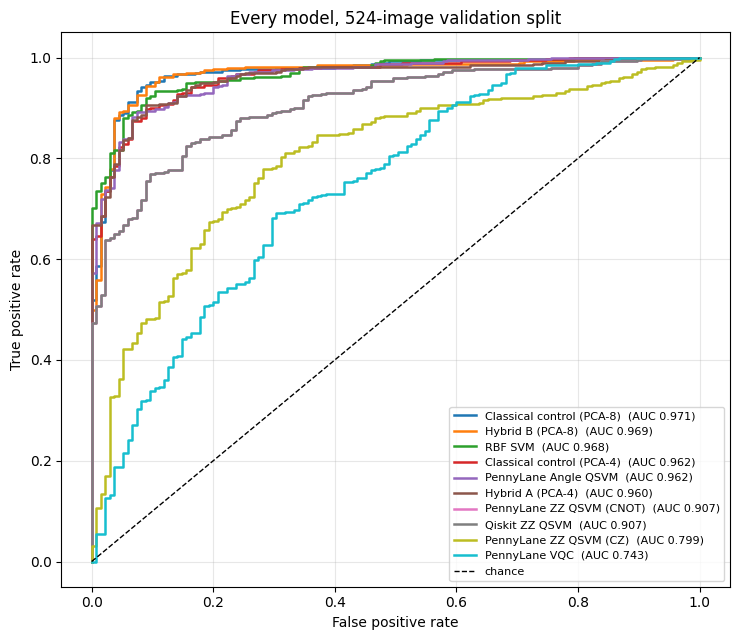

In [44]:
plt.figure(figsize=(7.5, 6.5))

for name, s in sorted(val_scores.items(), key=lambda kv: -roc_auc_score(y_val, kv[1])):
    fpr, tpr, _ = roc_curve(y_val, s)
    plt.plot(fpr, tpr, linewidth=1.8, label=f"{name}  (AUC {roc_auc_score(y_val, s):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Every model, 524-image validation split")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Held-out test split

Every choice made so far -- ansatz depth, encoding scale, entanglement pattern, which feature
map -- used the validation split, so those numbers are optimistic. The 624-image test split has
not been touched until now and is scored once. Thresholds still come from the training scores.

In [45]:
test_comparison = comparison_table(y_test, test_scores, "test")
test_comparison.insert(1, "val AUC", [
    round(roc_auc_score(y_val, val_scores[n]), 4) for n in test_comparison.Model
])

n1, n0 = int((y_test == 1).sum()), int((y_test == 0).sum())
se_test = np.sqrt((n1 + n0 + 1) / (12.0 * n1 * n0))
print(f"Test split: {n0} normal, {n1} pneumonia.  AUC standard error +/-{se_test:.4f}")

test_comparison

Test split: 234 normal, 390 pneumonia.  AUC standard error +/-0.0239


,Model,val AUC,test AUC,test bal acc,test acc
0,PennyLane Angle QSVM,0.9618,0.9147,0.8299,0.8173
1,Classical control (PCA-4),0.9625,0.9126,0.8231,0.8109
2,Hybrid A (PCA-4),0.9599,0.9095,0.8282,0.8173
3,RBF SVM,0.9683,0.8987,0.8145,0.8013
4,Hybrid B (PCA-8),0.9689,0.8951,0.8312,0.8478
5,Classical control (PCA-8),0.9710,0.8911,0.8145,0.8301
6,Qiskit ZZ QSVM,0.9074,0.8459,0.7252,0.7612
7,PennyLane ZZ QSVM (CNOT),0.9074,0.8459,0.7252,0.7612
8,PennyLane ZZ QSVM (CZ),0.7986,0.7481,0.6812,0.6378
9,PennyLane VQC,0.7429,0.6290,0.5923,0.5929


### What the test split shows

Every model scores lower on test than on validation, and the order changes: the two PCA-8
models that led on validation lose about 0.08 AUC, while the Angle QSVM, fourth on validation,
comes out on top. With a validation standard error of +/-0.029 the leading six were never
separable, so the reshuffle is what should be expected -- the validation ranking among them was
mostly noise. Only the large gaps survive the move between splits: the `CZ` feature map and the
standalone VQC stay at the bottom of both.

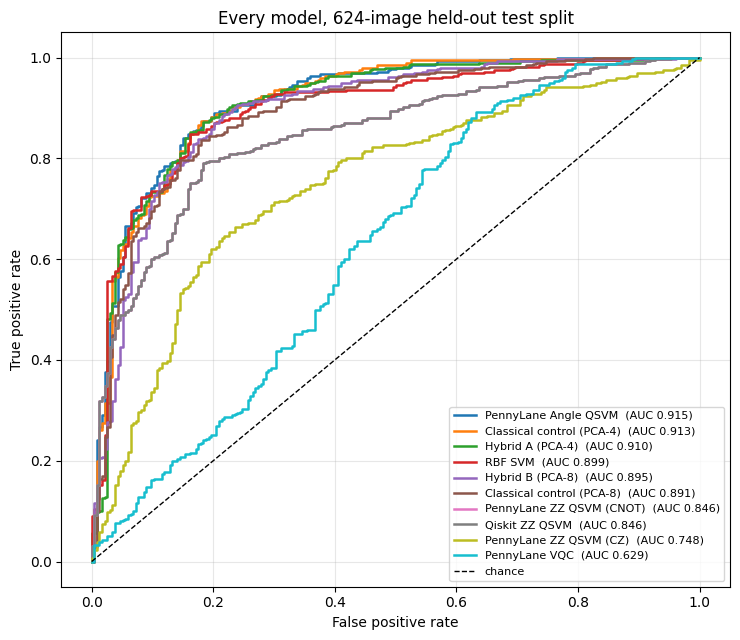

In [46]:
plt.figure(figsize=(7.5, 6.5))

for name, s in sorted(test_scores.items(), key=lambda kv: -roc_auc_score(y_test, kv[1])):
    fpr, tpr, _ = roc_curve(y_test, s)
    plt.plot(fpr, tpr, linewidth=1.8, label=f"{name}  (AUC {roc_auc_score(y_test, s):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1, label="chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Every model, 624-image held-out test split")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
import os

os.makedirs("results", exist_ok=True)

depth_sweep.to_csv("results/depth_sweep.csv", index=False)
multiseed.to_csv("results/multiseed_runs.csv", index=False)
multiseed_summary.to_csv("results/multiseed_summary.csv", index=False)
final_comparison.to_csv("results/validation_comparison.csv", index=False)
test_comparison.to_csv("results/test_comparison.csv", index=False)
np.savez("results/scores.npz",
         y_val=y_val, y_test=y_test,
         **{f"val__{k}": v for k, v in val_scores.items()},
         **{f"test__{k}": v for k, v in test_scores.items()})

print("\n".join(sorted(os.listdir("results"))))

completion_models.csv
completion_scores.npz
controls.npz
depth_sweep.csv
final_comparison.csv
fullval_comparison.csv
fullval_scores.npz
master_results.csv
multiseed_runs.csv
multiseed_summary.csv
scores.npz
test_comparison.csv
validation_comparison.csv


## 10. Summary

Everything here is trained on 100 balanced images and evaluated on the full 524-image
validation split (AUC standard error +/-0.029) and the 624-image test split (+/-0.024).
Differences smaller than about 0.06 are not interpretable.

### The book's ZZ feature map does not entangle

`CZ` and `RZ` are both diagonal and `CZ @ CZ = I`, so the pair sandwich collapses to a bare
`RZ`. Deleting every `CZ` changes the encoded state by exactly 0.0, and the state's
entanglement entropy is 2e-15 -- a product state. Swapping in `CNOT` gives entropy 0.63 and
reproduces Qiskit's `zz_feature_map` exactly: correlation 1.0000000000, scores agreeing to
8e-11, identical AUC to ten decimals. One non-diagonal gate accounts for the entire 0.109 AUC
gap between the two "ZZ" QSVMs, 0.7986 against 0.9074.

### The VQC failed for three separate reasons

Trained exactly as printed -- `PauliZ` readout, MSE against -1/+1 labels -- it predicted a
single class for every input, accuracy 0.50. Measuring the circuit rather than tuning it found
three independent causes:

- The linear `CNOT` chain runs away from the measured qubit, leaving 6 of 12 parameters with
  exactly zero gradient. Closing the ring drops that to 3, and those 3 are the trailing `RY`
  gates on unmeasured wires -- structurally inert at any depth, which the sweep confirms
  (`dead = 3` at every `reps`).
- `AngleEmbedding` reads radians, but the scaled features average 0.20 rad, so all 100 samples
  encoded to nearly the same state: output std 0.02, class separation 0.0005. Scaling by `pi`
  raises output spread 4.6x.
- With no trainable bias a 0.5 cut is arbitrary. Youden's J calibrated on training scores lifts
  validation accuracy from 0.60 to 0.62.

### Depth adds capacity, not generalization

Over 5 initializations, training AUC rises monotonically (0.719, 0.760, 0.793, 0.814, all with
std < 0.010) while validation AUC peaks at `reps=2` and the train/val gap widens after it
(0.037, 0.087, 0.116). `reps=2` is chosen on that gap and on parsimony, not on rank: paired
across seeds, `reps=2` against `reps=6` gives p = 0.196.

A single seed would have called `reps=1` worse than chance at 0.4672. Across five it is
0.6227 +/- 0.0870, with seed 42 the lone outlier -- depth 1 has an initialization failure mode
the deeper circuits do not, which is the opposite of what one seed suggested.


### No quantum advantage at this scale

The best quantum kernel, the Angle QSVM at 0.9618, ties the RBF SVM at 0.9683 well inside one
standard error, having taken 9.5 s to fit against 0.9 ms -- four orders of magnitude more
compute. It happens to lead the test split at 0.9147, but only within noise. Given 4-8 PCA
components carrying 60-73% of the variance and 100 training images, that is the expected
result, and reporting it is the point: the contribution here is a correctly diagnosed and
correctly measured pipeline, not a win.
